In [1]:
import pandas as pd
import numpy as np

# JTI Master Dataset for Practice
np.random.seed(42)
raw_data = {
    'Student_ID': [f'JTI_{i}' for i in range(101, 121)],
    'Course': ['Typing', 'Steno', 'Python', 'Excel', 'Typing', 'Steno', 'Python', 'Excel', 'Typing', 'Steno']*2,
    'Attendance_Per': [85, 45, 90, 30, 95, 50, 80, 40, 88, 35, 92, 42, 87, 28, 96, 55, 78, 38, 89, 33],
    'Practice_Hours': [40, 12, 45, 8, 50, 18, 38, 10, 42, 14, 48, 11, 43, 7, 52, 20, 36, 9, 44, 13],
    'Fees_Paid': [5000, 2000, 8000, 1500, 5200, 2500, 7800, 1200, 5100, 2200, 5300, 2100, 8200, 1100, 5400, 2600, 7600, 1300, 5000, 2400],
    'Final_Speed_WPM': [45, 20, 55, 15, 60, 22, 50, 18, 52, 21, 58, 19, 54, 14, 62, 23, 48, 17, 53, 20],
    'Exam_Cleared': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}
df_master = pd.DataFrame(raw_data)
print("Dataset Loaded Successfully! Total Rows & Cols:", df_master.shape)

Dataset Loaded Successfully! Total Rows & Cols: (20, 7)


In [2]:
df_master

,Student_ID,Course,Attendance_Per,Practice_Hours,Fees_Paid,Final_Speed_WPM,Exam_Cleared
0,JTI_101,Typing,85,40,5000,45,1
1,JTI_102,Steno,45,12,2000,20,0
2,JTI_103,Python,90,45,8000,55,1
3,JTI_104,Excel,30,8,1500,15,0
4,JTI_105,Typing,95,50,5200,60,1
5,JTI_106,Steno,50,18,2500,22,0
6,JTI_107,Python,80,38,7800,50,1
7,JTI_108,Excel,40,10,1200,18,0
8,JTI_109,Typing,88,42,5100,52,1
9,JTI_110,Steno,35,14,2200,21,0


In [3]:
df_master.shape

(20, 7)

In [4]:
df_master.isnull().sum()

Student_ID         0
Course             0
Attendance_Per     0
Practice_Hours     0
Fees_Paid          0
Final_Speed_WPM    0
Exam_Cleared       0
dtype: int64

In [5]:
df_master.drop(['Student_ID'],axis=1,inplace=True)

In [6]:
df_master

,Course,Attendance_Per,Practice_Hours,Fees_Paid,Final_Speed_WPM,Exam_Cleared
0,Typing,85,40,5000,45,1
1,Steno,45,12,2000,20,0
2,Python,90,45,8000,55,1
3,Excel,30,8,1500,15,0
4,Typing,95,50,5200,60,1
5,Steno,50,18,2500,22,0
6,Python,80,38,7800,50,1
7,Excel,40,10,1200,18,0
8,Typing,88,42,5100,52,1
9,Steno,35,14,2200,21,0


In [7]:
df_high=df_master.apply(lambda x: df_master['Attendance']>80)

KeyError: 'Attendance'

In [8]:
df_master

,Course,Attendance_Per,Practice_Hours,Fees_Paid,Final_Speed_WPM,Exam_Cleared
0,Typing,85,40,5000,45,1
1,Steno,45,12,2000,20,0
2,Python,90,45,8000,55,1
3,Excel,30,8,1500,15,0
4,Typing,95,50,5200,60,1
5,Steno,50,18,2500,22,0
6,Python,80,38,7800,50,1
7,Excel,40,10,1200,18,0
8,Typing,88,42,5100,52,1
9,Steno,35,14,2200,21,0


In [9]:
from pandasql import sqldf
query="""
SELECT Course,Fees_Paid
FROM df_master
GROUPBY Course
HAVING Fees_Paid
"""
sqldf(query)

PandaSQLException: (sqlite3.OperationalError) near "Course": syntax error
[SQL: 
SELECT Course,Fees_Paid
FROM df_master
GROUPBY Course
HAVING Fees_Paid
]
(Background on this error at: https://sqlalche.me/e/14/e3q8)

In [10]:
from pandasql import sqldf
query="""
SELECT Final_Speed_WPM
FROM df_master
ORDERBY Final_Speed_WPM ASC;
"""
sqldf(query)


PandaSQLException: (sqlite3.OperationalError) near "Final_Speed_WPM": syntax error
[SQL: 
SELECT Final_Speed_WPM
FROM df_master
ORDERBY Final_Speed_WPM ASC;
]
(Background on this error at: https://sqlalche.me/e/14/e3q8)

In [11]:
df_master.groupby('Course')['Fees_Paid'].mean()

Course
Excel     1275.000000
Python    7900.000000
Steno     2300.000000
Typing    5166.666667
Name: Fees_Paid, dtype: float64

In [12]:
df_master['Practice_Hours'].std()

16.842927611502574

In [13]:
df_master['Z_score_speed']=

SyntaxError: invalid syntax (3969278545.py, line 1)

In [14]:
df_master['Final_Speed_WPM'].mean()

36.3

In [15]:
df_master['Final_Speed_WPM'].median()

34.0

<Axes: >

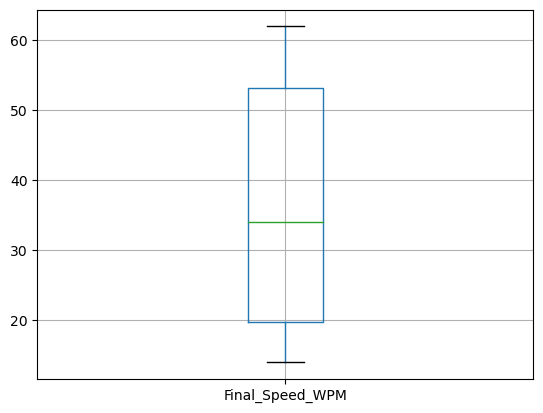

In [16]:
df_master.boxplot(column=['Final_Speed_WPM'])

In [23]:
df_master=pd.get_dummies(df_master,columns=['Course'],drop_first=True)


KeyError: "None of [Index(['Course'], dtype='object')] are in the [columns]"

In [24]:
df_master

,Attendance_Per,Practice_Hours,Fees_Paid,Final_Speed_WPM,Exam_Cleared,Course_Python,Course_Steno,Course_Typing
0,85,40,5000,45,1,False,False,True
1,45,12,2000,20,0,False,True,False
2,90,45,8000,55,1,True,False,False
3,30,8,1500,15,0,False,False,False
4,95,50,5200,60,1,False,False,True
5,50,18,2500,22,0,False,True,False
6,80,38,7800,50,1,True,False,False
7,40,10,1200,18,0,False,False,False
8,88,42,5100,52,1,False,False,True
9,35,14,2200,21,0,False,True,False


In [25]:
X=df_master.drop('Exam_Cleared',axis=1)
y=df_master['Exam_Cleared']

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)

In [28]:
from sklearn.svm import SVC
final_mod=SVC(kernel='rbf',C=1.0,gamma='scale')
final_mod.fit(X_train_scaled,y_train)

SVC()

In [31]:
from sklearn.metrics import classification_report,accuracy_score
pred=final_mod.predict(X_test_scaled)
print(f"classification report : {classification_report(y_test,pred)}")
print(f"accuracy score is: {accuracy_score(y_test,pred)*100:.2f}%")

classification report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

accuracy score is: 100.00%


In [32]:
X=df_master.drop('Final_Speed_WPM',axis=1)
y=df_master['Final_Speed_WPM']

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)
finalm=DecisionTreeRegressor(max_depth=3,min_samples_split=4,min_samples_leaf=2,random_state=42)
finalm.fit(X_train_scaled,y_train)
predi=finalm.predict(X_test_scaled)
print(f"rmse score is: {np.sqrt(mean_squared_error(y_test,predi)):.2f}")
print(f"r2 score is: {r2_score(y_test,predi)*100:.2f}%")


rmse score is: 4.49
r2 score is: 83.41%


In [38]:
import matplotlib.pyplot as plt
from sklearn import tree

<Figure size 1200x800 with 0 Axes>

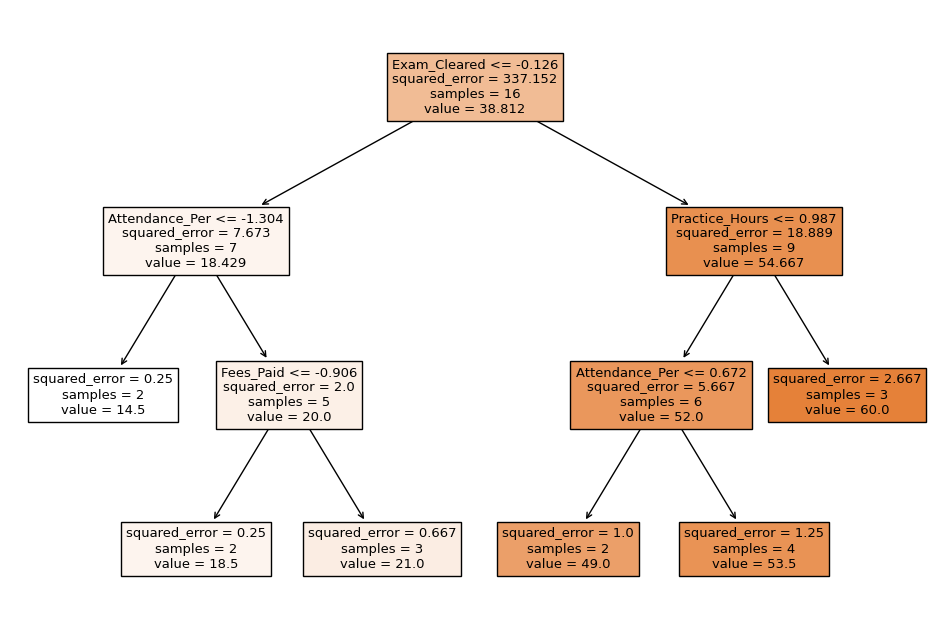

In [39]:
plt.figure(figsize=(12,8))
tree.plot_tree(finalm,filled=True,feature_names=list(X.columns))
plt.show()

In [40]:
train_pred=finalm.predict(X_train_scaled)
test_pred=finalm.predict(X_test_scaled)
print(f"train r2 prediction score: {r2_score(y_train,train_pred)*100:.2f}%")
print(f"test r2 prediction score: {r2_score(y_test,test_pred)*100:.2f}%")

train r2 prediction score: 99.67%
test r2 prediction score: 83.41%


In [41]:
import pandas as pd
import numpy as np

# JTI New Sunday Master Dataset
np.random.seed(55)
sunday_data = {
    'Student_Name': [f'CEO_{i}' for i in range(1, 21)],
    'Batch_Type': ['FastTrack', 'Regular', 'Weekend', 'Regular', 'FastTrack']*4,
    'Python_Score': [82, 41, 88, 32, 95, 48, 79, 36, 85, 30, 91, 45, 84, 29, 96, 51, 75, 40, 89, 34],
    'SQL_Score': [78, 38, 85, 30, 92, 44, 76, 33, 80, 28, 88, 42, 81, 25, 94, 49, 72, 35, 86, 31],
    'Hours_Studied': [35, 10, 42, 6, 48, 15, 34, 8, 38, 12, 44, 11, 40, 5, 50, 18, 32, 9, 41, 13],
    'Placed': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0] # Target for Classification
}
df_jti_sunday = pd.DataFrame(sunday_data)
print("Sunday Battleground Ready! Shape:", df_jti_sunday.shape)


Sunday Battleground Ready! Shape: (20, 6)


In [57]:
df_jti_sunday


,Student_Name,Batch_Type,Python_Score,SQL_Score,Hours_Studied,Placed
0,CEO_1,FastTrack,82,78,35,1
1,CEO_2,Regular,41,38,10,0
2,CEO_3,Weekend,88,85,42,1
3,CEO_4,Regular,32,30,6,0
4,CEO_5,FastTrack,95,92,48,1
5,CEO_6,FastTrack,48,44,15,0
6,CEO_7,Regular,79,76,34,1
7,CEO_8,Weekend,36,33,8,0
8,CEO_9,Regular,85,80,38,1
9,CEO_10,FastTrack,30,28,12,0


In [58]:
df_jti_sunday.shape

(20, 6)

In [59]:
df_jti_sunday.isnull().sum()

Student_Name     0
Batch_Type       0
Python_Score     0
SQL_Score        0
Hours_Studied    0
Placed           0
dtype: int64

In [65]:
df_toppers=df_jti_sunday[(df_jti_sunday['Python_Score']>80) & (df_jti_sunday['SQL_Score']>80)]

In [67]:
df_toppers

,Student_Name,Batch_Type,Python_Score,SQL_Score,Hours_Studied,Placed
2,CEO_3,Weekend,88,85,42,1
4,CEO_5,FastTrack,95,92,48,1
10,CEO_11,FastTrack,91,88,44,1
12,CEO_13,Weekend,84,81,40,1
14,CEO_15,FastTrack,96,94,50,1
18,CEO_19,Regular,89,86,41,1


In [61]:
df_jti_sunday.groupby('Batch_Type')['SQL_Score'].mean()

Batch_Type
FastTrack    63.000
Regular      56.125
Weekend      58.500
Name: SQL_Score, dtype: float64

In [62]:
from pandasql import sqldf
q="""
SELECT Batch_Type,SUM(Hours_Studied) As Total_Hours
FROM df_jti_sunday
GROUP BY Batch_Type
ORDER BY Total_Hours DESC

"""
sqldf(q)

,Batch_Type,Total_Hours
0,FastTrack,235
1,Regular,177
2,Weekend,99


In [68]:
df_jti_sunday['Hours_Z_Score'] = (df_jti_sunday['Hours_Studied'] - df_jti_sunday['Hours_Studied'].mean()) / df_jti_sunday['Hours_Studied'].std()

In [69]:
df_jti_sunday

,Student_Name,Batch_Type,Python_Score,SQL_Score,Hours_Studied,Placed,Hours_Z_Score
0,CEO_1,FastTrack,82,78,35,1,0.590446
1,CEO_2,Regular,41,38,10,0,-0.971580
2,CEO_3,Weekend,88,85,42,1,1.027813
3,CEO_4,Regular,32,30,6,0,-1.221505
4,CEO_5,FastTrack,95,92,48,1,1.402700
5,CEO_6,FastTrack,48,44,15,0,-0.659175
6,CEO_7,Regular,79,76,34,1,0.527965
7,CEO_8,Weekend,36,33,8,0,-1.096543
8,CEO_9,Regular,85,80,38,1,0.777889
9,CEO_10,FastTrack,30,28,12,0,-0.846618


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# New Dataset: Amazon Product Returns
sales_data = {
    'Product_ID': ['P101', 'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P109', 'P110'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', 'Home'],
    'Price_INR': [15000, 1200, 25000, 3000, 800, 45000, 5000, 1500, 12000, 4000],
    'Discount_Pct': [10, 50, 5, 20, 60, 2, 15, 45, 12, 18],
    'Is_Returned': [0, 1, 0, 0, 1, 0, 0, 1, 0, 0] # 1 = Product Wapas aaya, 0 = Nahi aaya
}
df_amazon = pd.DataFrame(sales_data)
print("Amazon Data Loaded! Shape:", df_amazon.shape)

Amazon Data Loaded! Shape: (10, 5)


In [71]:
df_amazon

,Product_ID,Category,Price_INR,Discount_Pct,Is_Returned
0,P101,Electronics,15000,10,0
1,P102,Clothing,1200,50,1
2,P103,Electronics,25000,5,0
3,P104,Home,3000,20,0
4,P105,Clothing,800,60,1
5,P106,Electronics,45000,2,0
6,P107,Home,5000,15,0
7,P108,Clothing,1500,45,1
8,P109,Electronics,12000,12,0
9,P110,Home,4000,18,0


In [73]:
df_amazon['Price_INR'].mean()

11250.0

In [74]:
df_amazon['Price_INR'].median()

4500.0

In [ ]:
df_master.boxplot(column=['Final_Speed_WPM'])

In [78]:
df_amazon.boxplot(column=['Price_INR'])

<Axes: >

In [80]:
X=df_amazon[['Price_INR','Discount_Pct']]
y=df_amazon['Is_Returned']

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
finalmo=DecisionTreeClassifier(max_depth=2, min_samples_split=3,min_samples_leaf=1,random_state=42)
finalmo.fit(X_train,y_train)
predict=finalmo.predict(X_test)
print(f"the accuracy score is : {accuracy_score(y_test,predict)*100:.2f}%")


the accuracy score is : 100.00%


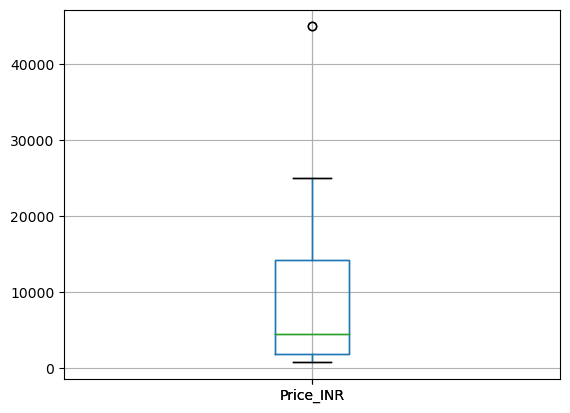

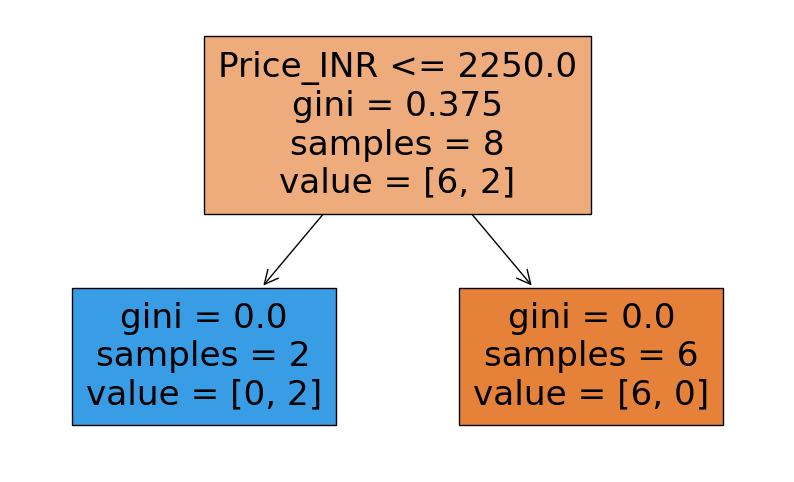

In [91]:
plt.figure(figsize=(10,6))
tree.plot_tree(finalmo,filled=True,feature_names=list(X.columns))
plt.show()

In [92]:
import pandas as pd
import numpy as np

# New Dataset: JTI City Hospital
hospital_data = {
    'Patient_ID': ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8'],
    'Age': [25, 55, 62, 30, 45, 70, 28, 58],
    'Blood_Sugar': [90, 150, np.nan, 95, 110, 180, 85, np.nan], # np.nan matlab Missing Data
    'Heart_Rate': [72, 88, 95, 70, 80, 100, 75, 90],
    'Admitted': [0, 1, 1, 0, 0, 1, 0, 1] # 1 = ICU mein admit, 0 = Ghar bheja
}
df_hospital = pd.DataFrame(hospital_data)
print("Hospital Data Loaded! Shape:", df_hospital.shape)

Hospital Data Loaded! Shape: (8, 5)


In [93]:
df_hospital

,Patient_ID,Age,Blood_Sugar,Heart_Rate,Admitted
0,H1,25,90.0,72,0
1,H2,55,150.0,88,1
2,H3,62,NaN,95,1
3,H4,30,95.0,70,0
4,H5,45,110.0,80,0
5,H6,70,180.0,100,1
6,H7,28,85.0,75,0
7,H8,58,NaN,90,1


In [97]:
df_hospital.isnull().sum()

Patient_ID     0
Age            0
Blood_Sugar    2
Heart_Rate     0
Admitted       0
dtype: int64

In [98]:
a=df_hospital['Blood_Sugar'].mean()

In [99]:
a

118.33333333333333

In [100]:
df_hospital.fillna({'Blood_Sugar':a},inplace=True)
df_hospital

,Patient_ID,Age,Blood_Sugar,Heart_Rate,Admitted
0,H1,25,90.000000,72,0
1,H2,55,150.000000,88,1
2,H3,62,118.333333,95,1
3,H4,30,95.000000,70,0
4,H5,45,110.000000,80,0
5,H6,70,180.000000,100,1
6,H7,28,85.000000,75,0
7,H8,58,118.333333,90,1


In [105]:
df_risk=df_hospital[(df_hospital['Blood_Sugar']>120)&(df_hospital['Age']>50)]

In [117]:
df_risk

,Patient_ID,Age,Blood_Sugar,Heart_Rate,Admitted
1,H2,55,150.0,88,1
5,H6,70,180.0,100,1


In [104]:
df_hospital.groupby('Admitted')['Heart_Rate'].mean()

Admitted
0    74.25
1    93.25
Name: Heart_Rate, dtype: float64

In [109]:
df_hospital['HR_Z_Score']=(df_hospital['Heart_Rate']-df_hospital['Heart_Rate'].mean())/df_hospital['Heart_Rate'].std()

In [110]:
df_hospital

,Patient_ID,Age,Blood_Sugar,Heart_Rate,Admitted,HR_Z_Score
0,H1,25,90.000000,72,0,-1.056704
1,H2,55,150.000000,88,1,0.382212
2,H3,62,118.333333,95,1,1.011738
3,H4,30,95.000000,70,0,-1.236569
4,H5,45,110.000000,80,0,-0.337246
5,H6,70,180.000000,100,1,1.461399
6,H7,28,85.000000,75,0,-0.786907
7,H8,58,118.333333,90,1,0.562077


In [107]:
X=df_hospital[['Blood_Sugar','Heart_Rate']]
y=df_hospital['Admitted']

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_scaled=scale.fit_transform(X)
finalmodel1=SVC(kernel='rbf',C=1.0,gamma='scale')
finalmodel1.fit(X_scaled,y)
predictt=finalmodel1.predict(X_scaled)
print(f"accuracy_score: {accuracy_score(y,predictt)*100:.2f}%")


accuracy_score: 100.00%


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# JTI HR Analytics Dataset (Find the hidden story!)
np.random.seed(99)
hr_data = {
    'Emp_ID': [f'EMP_{i}' for i in range(1, 16)],
    'Department': ['IT', 'HR', 'Sales', 'IT', 'Finance', 'IT', 'Sales', 'HR', 'Finance', 'IT', 'Sales', 'IT', 'HR', 'Finance', 'Sales'],
    'Years_Exp': [2, 5, 1, 8, np.nan, 3, 10, 4, 7, 2, np.nan, 6, 3, 9, 1],
    'Salary_INR': [50000, 75000, 40000, 120000, 95000, 60000, 150000, 65000, 110000, 45000, 55000, 85000, 70000, 130000, 380000], 
    'Left_Company': [0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1] # 1 = Chhod diya, 0 = Abhi bhi hai
}
df_hr = pd.DataFrame(hr_data)
print("HR Data Loaded! Shape:", df_hr.shape)

HR Data Loaded! Shape: (15, 5)


In [119]:
df_hr

,Emp_ID,Department,Years_Exp,Salary_INR,Left_Company
0,EMP_1,IT,2.0,50000,0
1,EMP_2,HR,5.0,75000,1
2,EMP_3,Sales,1.0,40000,1
3,EMP_4,IT,8.0,120000,0
4,EMP_5,Finance,NaN,95000,0
5,EMP_6,IT,3.0,60000,0
6,EMP_7,Sales,10.0,150000,0
7,EMP_8,HR,4.0,65000,1
8,EMP_9,Finance,7.0,110000,0
9,EMP_10,IT,2.0,45000,1


In [120]:
df_hr.shape

(15, 5)

In [121]:
df_hr.isnull().sum()

Emp_ID          0
Department      0
Years_Exp       2
Salary_INR      0
Left_Company    0
dtype: int64

In [122]:
b=df_hr['Years_Exp'].median()

In [123]:
b

4.0

In [124]:
df_hr.fillna({'Years_Exp':b},inplace=True)

In [126]:
df_hr

,Emp_ID,Department,Years_Exp,Salary_INR,Left_Company
0,EMP_1,IT,2.0,50000,0
1,EMP_2,HR,5.0,75000,1
2,EMP_3,Sales,1.0,40000,1
3,EMP_4,IT,8.0,120000,0
4,EMP_5,Finance,4.0,95000,0
5,EMP_6,IT,3.0,60000,0
6,EMP_7,Sales,10.0,150000,0
7,EMP_8,HR,4.0,65000,1
8,EMP_9,Finance,7.0,110000,0
9,EMP_10,IT,2.0,45000,1


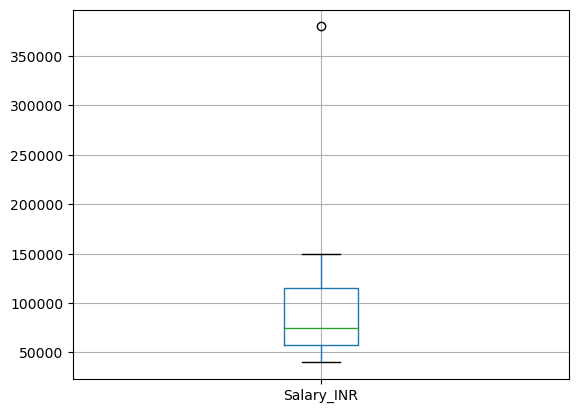

In [129]:
df_hr.boxplot(column=['Salary_INR'])
plt.show()

In [130]:
df_hr.groupby('Department')['Salary_INR'].max()

Department
Finance    130000
HR          75000
IT         120000
Sales      380000
Name: Salary_INR, dtype: int64

In [131]:
df_churn=df_hr[(df_hr['Years_Exp']>4)&(df_hr['Left_Company']==1)]

In [132]:
df_churn

,Emp_ID,Department,Years_Exp,Salary_INR,Left_Company
1,EMP_2,HR,5.0,75000,1
